In [2]:
#import relevant libraries
#Load modules
import os
import pandas as pd
import numpy as np
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
import seaborn as sns
import dabest
from struct import *
import osar
import scipy as sp
import re
import dabest

import warnings
from datetime import datetime
#import scikits.bootstrap as skb
from osar.plot_helpers.plot_helpers import r2_and_slope
date = datetime.today().strftime('%Y%m%d')

import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)

In [13]:
basegenotype = "SS77383"
responder = "ACR"
wt = "w1118"
addNotes = basegenotype + " x " + responder
trans = addNotes

officecomp = "C:\\Users\\Star\\"
labcomp = "C:\\Users\\User\\"
computer2 = "C:\\Users\\lnico\\"
homecomp = "D:\\"
filedirectory_OSAR = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\DATA\\OSAR\\"
specifiedpath = labcomp

baseDirectory_OSAR = specifiedpath + filedirectory_OSAR + addNotes


#OSAR related files
if len(addNotes) > 0:
    addNotes = "_" + addNotes   
filename_O = baseDirectory_OSAR + "\\" + basegenotype
filename_AppendDT = "_gen " + date
filename_O = filename_O + addNotes + filename_AppendDT

filename_O

'C:\\Users\\User\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\DATA\\OSAR\\SS77383 x ACR\\SS77383_SS77383 x ACR_gen 20260227'

In [14]:
def singleplottingdabest(dfi, names, parameter):
    dfrr = pd.DataFrame()
    filter1 = dfi[(dfi['status'] == 'Offspring')].copy().reset_index(drop=True)
    filter2 = dfi[(dfi['status'] == 'Sibling')].copy().reset_index(drop=True)

    dfrr[names + " Cntrl" ] = filter2[parameter]
    dfrr[names + " Test"] = filter1[parameter]
    #dfr1 = pd.concat([dfr1, dfrr], axis = 1)
        
    l = dfrr.columns.tolist()
    titlelst = list(zip(l,l[1:]))[::2]  
    test = dabest.load(dfrr, idx=titlelst)    
    
    return test

## Already have file

In [15]:
dir1 = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\2025collection\\"
files2 = dir1 + trans + ".csv"
df=pd.read_csv(files2)

In [31]:
df.columns.tolist()

['flyid',
 'exptDate',
 'driver',
 'expt_time_start',
 'genotype',
 'opsin',
 'light_intensity',
 'light_color',
 'status',
 'reversals_to_light_BASELINE',
 'traversals_to_light_BASELINE',
 'reversals_to_dark_BASELINE',
 'traversals_to_dark_BASELINE',
 'light_attraction_index_BASELINE',
 'pi_smoothed_BASELINE',
 'log2_speed_ratio_BASELINE',
 'distance_in_light_BASELINE',
 'time_in_light_BASELINE',
 'distance_in_dark_BASELINE',
 'time_in_dark_BASELINE',
 'time_moving_in_light_BASELINE',
 'time_moving_in_dark_BASELINE',
 'speed_in_light_BASELINE',
 'speed_in_dark_BASELINE',
 'speed_ratio_BASELINE',
 'pace_in_light_BASELINE',
 'pace_in_dark_BASELINE',
 'log2_pace_ratio_BASELINE',
 'pace_ratio_BASELINE',
 'bouts_in_light_BASELINE',
 'bouts_in_dark_BASELINE',
 'avg_bout_duration_light_BASELINE',
 'avg_bout_duration_dark_BASELINE',
 'max_velocity_light_BASELINE',
 'max_velocity_dark_BASELINE',
 'bout_index_BASELINE',
 'bout_duration_ratio_BASELINE',
 'max_velocity_ratio_BASELINE',
 'time_in_

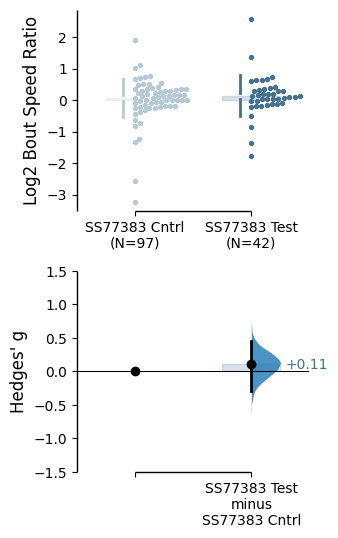

In [42]:
full_light = df[df["light_intensity"] == "Full"].reset_index(drop=True)
full_light['log2_pace_ratio_Pattern 01'] = full_light['log2_pace_ratio_Pattern 01'].replace([np.inf, -np.inf], np.nan)
singleplottingdabest(full_light, basegenotype,'log2_pace_ratio_Pattern 01').hedges_g.plot(float_contrast=False, fontsize_rawylabel=12, fontsize_rawxlabel=10, 
                                                                      fontsize_contrastxlabel=10, fontsize_contrastylabel=12, raw_marker_size=2, contrast_marker_size=6, 
                                                                      custom_palette="Paired", raw_label= "Log2 Bout Speed Ratio", contrast_ylim=(-1.5,1.5), contrast_label="Hedges' g");

## No compiled .csv file

In [7]:
# IF no current file already

osarAnalysis = osar.osar(baseDirectory_OSAR,
                        # border_shift_mm = 1.5,  
                        # countlog_folder = "countlog_Full Only",         
                        # countlog_folder = "countlog_Half and Full",
                         driver = basegenotype)

Creating borders for each fly...
Done.

Processing CSV 64 of 64
Summarising results for all flies...
All done.


In [ ]:
full_light = osarAnalysis.results[osarAnalysis.results['light_intensity'] == "Full"]
singleplottingdabest(full_light, basegenotype,'log2_speed_ratio_Pattern 01').mean_diff.plot(float_contrast=False, fontsize_rawylabel=8, fontsize_rawxlabel=8, 
                                                                      fontsize_contrastxlabel=8, fontsize_contrastylabel=8, raw_marker_size=2, contrast_marker_size=6, 
                                                                      custom_palette="Paired", contrast_label="pi_smoothed_Pattern 01", contrast_ylim=(-1.5,1.5));

NameError: name 'osarAnalysis' is not defined

In [ ]:
full_light = osarAnalysis.results[osarAnalysis.results['light_intensity'] == "Full"]
singleplottingdabest(full_light, basegenotype,'pi_smoothed_Pattern 01').mean_diff.plot(float_contrast=False, fontsize_rawylabel=8, fontsize_rawxlabel=8, 
                                                                      fontsize_contrastxlabel=8, fontsize_contrastylabel=8, raw_marker_size=2, contrast_marker_size=6, 
                                                                      custom_palette="Paired", contrast_label="pi_smoothed_Pattern 01", contrast_ylim=(-1.5,1.5));